<a href="https://colab.research.google.com/github/aman2003selwaria/Desktop-application-_-Notepad/blob/main/Assignment_2_pet_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train shape: (10000, 32, 32, 3) (10000, 1)
Test shape: (2000, 32, 32, 3) (2000, 1)


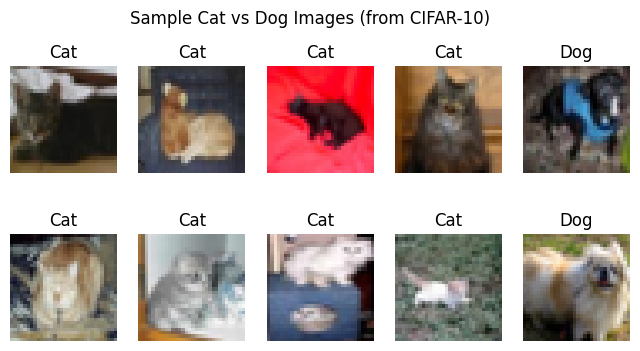

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,889 (429.25 KB)

 Trainable params: 109,889 (429.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 - 23s - 184ms/step - accuracy: 0.4926 - loss: 0.6937 - val_accuracy: 0.4975 - val_loss: 0.6929
Epoch 2/10
125/125 - 37s - 298ms/step - accuracy: 0.5226 - loss: 0.6923 - val_accuracy: 0.5005 - val_loss: 0.6904
Epoch 3/10
125/125 - 16s - 126ms/step - accuracy: 0.5514 - loss: 0.6843 - val_accuracy: 0.5785 - val_loss: 0.6746
Epoch 4/10
125/125 - 26s - 209ms/step - accuracy: 0.5969 - loss: 0.6691 - val_accuracy: 0.6120 - val_loss: 0.6509
Epoch 5/10
125/125 - 35s - 281ms/step - accuracy: 0.6192 - loss: 0.6519 - val_accuracy: 0.6310 - val_loss: 0.6362
Epoch 6/10
125/125 - 16s - 125ms/step - accuracy: 0.6455 - loss: 0.6320 - val_accuracy: 0.6410 - val_loss: 0.6273
Epoch 7/10
125/125 - 23s - 183ms/step - accuracy: 0.6814 - loss: 0.5987 - val_accuracy: 0.6780 - val_loss: 0.6003
Epoch 8/10
125/125 - 15s - 122ms/step - accuracy: 0.6982 - loss: 0.5782 - val_accuracy: 0.7175 - val_loss: 0.5628
Epoch 9/10
125/125 - 21s - 166ms/step - accuracy: 0.7201 - loss: 0.5546 - val_accuracy: 

In [ ]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()


train_filter = np.where((y_train == 3) | (y_train == 5))[0]
test_filter = np.where((y_test == 3) | (y_test == 5))[0]

x_train, y_train = x_train[train_filter], y_train[train_filter]
x_test, y_test = x_test[test_filter], y_test[test_filter]


y_train = (y_train == 5).astype("int")
y_test = (y_test == 5).astype("int")


x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

class_names = ["Cat", "Dog"]
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]] if y_train.ndim>1 else class_names[y_train[i]])
    plt.axis("off")
plt.suptitle("Sample Cat vs Dog Images (from CIFAR-10)")
plt.show()

def build_cnn():
    model = keras.Sequential([
        keras.Input(shape=(32,32,3)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

cnn_model = build_cnn()
cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn_model.summary()

history_cnn = cnn_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    verbose=2
)


cnn_loss, cnn_acc = cnn_model.evaluate(x_test, y_test, verbose=2)
print(f"\nCNN Test Accuracy: {cnn_acc:.4f}")

IMG_SIZE = (224,224)


def resize_images(x):
    return np.array([tf.image.resize(img, IMG_SIZE).numpy() for img in x])

x_train_resized = resize_images(x_train)
x_test_resized = resize_images(x_test)


y_train_catdog = keras.utils.to_categorical(y_train, 2)
y_test_catdog = keras.utils.to_categorical(y_test, 2)


data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SIZE+(3,), include_top=False, weights="imagenet"
)
base_model.trainable = False

inputs = keras.Input(shape=IMG_SIZE+(3,))
x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(2, activation="softmax")(x)

transfer_model = keras.Model(inputs, outputs)
transfer_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                       loss="categorical_crossentropy",
                       metrics=["accuracy"])
transfer_model.summary()


history_transfer = transfer_model.fit(
    x_train_resized, y_train_catdog,
    validation_split=0.2,
    epochs=8,
    batch_size=32,
    verbose=2
)

base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

transfer_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                       loss="categorical_crossentropy",
                       metrics=["accuracy"])

history_fine = transfer_model.fit(
    x_train_resized, y_train_catdog,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=2
)

transfer_loss, transfer_acc = transfer_model.evaluate(x_test_resized, y_test_catdog, verbose=2)
print(f"\nTransfer Learning Test Accuracy: {transfer_acc:.4f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history_cnn.history["accuracy"], label="CNN Train")
plt.plot(history_cnn.history["val_accuracy"], label="CNN Val")
plt.legend(); plt.title("CNN Accuracy")

plt.subplot(1,2,2)
plt.plot(history_transfer.history["accuracy"], label="TL Train")
plt.plot(history_transfer.history["val_accuracy"], label="TL Val")
plt.plot(history_fine.history["accuracy"], label="FT Train")
plt.plot(history_fine.history["val_accuracy"], label="FT Val")
plt.legend(); plt.title("Transfer Learning Accuracy")
plt.show()

preds = transfer_model.predict(x_test_resized[:10])
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i])
    true_label = class_names[y_test[i][0]] if y_test.ndim>1 else class_names[y_test[i]]
    pred_label = class_names[np.argmax(preds[i])]
    color = "green" if true_label==pred_label else "red"
    plt.title(f"T:{true_label}\nP:{pred_label}", color=color, fontsize=9)
    plt.axis("off")
plt.suptitle("Sample Cat vs Dog Predictions (Transfer Learning)")
plt.show()
